In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("loan_data.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        949 non-null    float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB
None


In [3]:
df['income']=df['income'].fillna(df['income'].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        1000 non-null   float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


In [4]:
df.describe()

,loan_id,age,income,loan_amount,credit_score,default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,43.862000,50010.146000,39376.065000,569.330000,0.202000
std,288.819436,15.350133,15007.616205,106044.548426,158.685734,0.401693
min,1001.000000,18.000000,4424.000000,-9108.000000,300.000000,0.000000
25%,1250.750000,30.000000,40410.250000,9812.250000,428.750000,0.000000
50%,1500.500000,44.000000,49712.000000,15645.500000,564.000000,0.000000
75%,1750.250000,58.000000,60099.500000,21816.500000,708.000000,0.000000
max,2000.000000,69.000000,93872.000000,500000.000000,849.000000,1.000000


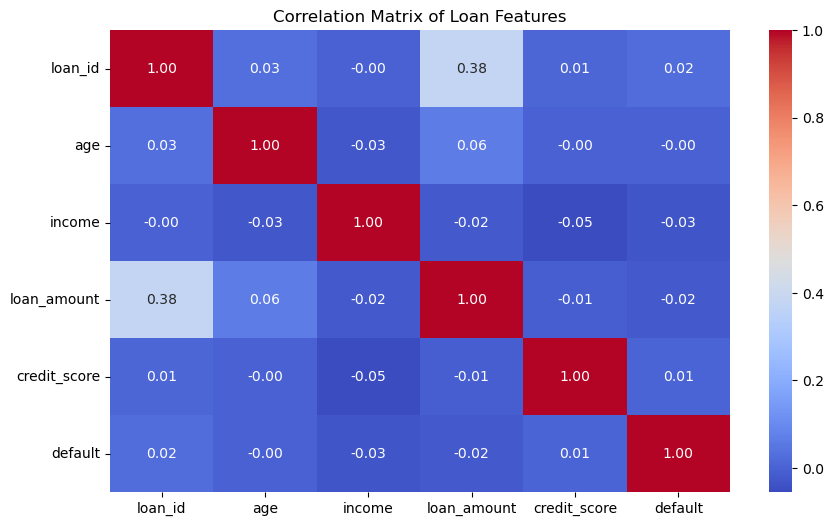

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix of Loan Features")
plt.show()

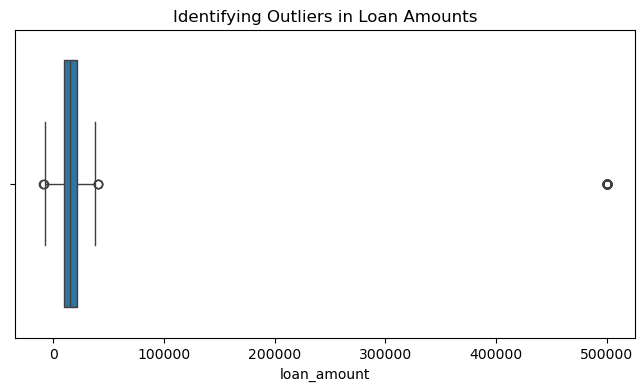

In [6]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['loan_amount'])
plt.title("Identifying Outliers in Loan Amounts")
plt.show()

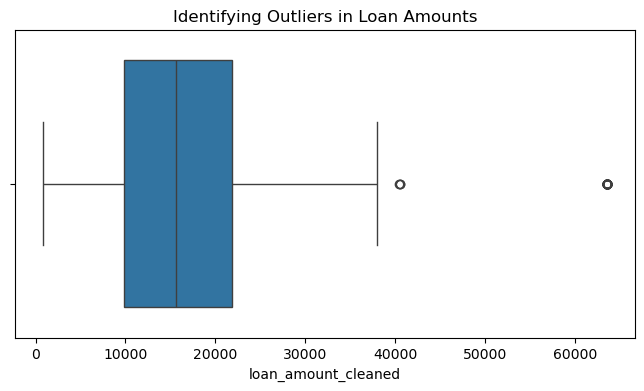

In [16]:
qu_limit=df['loan_amount'].quantile(0.95)
ql_limit=df['loan_amount'].quantile(0.05)
df['loan_amount_cleaned']=df['loan_amount'].clip(upper=qu_limit,lower=ql_limit)
plt.figure(figsize=(8,4))
sns.boxplot(x=df['loan_amount_cleaned'])
plt.title("Identifying Outliers in Loan Amounts")
plt.show()

Step 4 : Feature Engineering 

In [19]:
# Create New Features 
df['dti_ratio']=df['loan_amount_cleaned']/df['income']
bins=[300,500,670,740,850]
labels=['High Risk','Fair','Good','Excellent']
df['risk_category']=pd.cut(df['credit_score'],bins=bins,labels=labels)
print(df[['income','loan_amount_cleaned','dti_ratio','risk_category']].head())

    income  loan_amount_cleaned  dti_ratio risk_category
0  49712.0              11515.0   0.231634     High Risk
1  49712.0              26673.0   0.536551          Good
2  49712.0              11267.0   0.226645     High Risk
3  49712.0              11561.0   0.232560     High Risk
4  49712.0              19316.0   0.388558     High Risk


In [22]:
summary=df.groupby('risk_category',observed=False)['default'].mean()*100
print(f"Default Percentage by Category:\n{summary}")

Default Percentage by Category:
risk_category
High Risk    20.472441
Fair         18.581081
Good         19.259259
Excellent    22.994652
Name: default, dtype: float64
